# Uniform Distribution

The **Uniform distribution** assigns equal probability to every point in an interval [A, B]. It is the simplest continuous distribution and is the foundation for random number generation — almost all RNGs produce Uniform(0,1) values from which all other distributions are derived.

| Property | Value |
|---|---|
| **Parameters** | A (lower bound), B (upper bound), A < B |
| **Support** | [A, B] |
| **PDF** | f(x) = 1/(B−A) for A ≤ x ≤ B, else 0 |
| **CDF** | F(x) = (x−A)/(B−A) |
| **Mean** | (A+B)/2 |
| **Median** | (A+B)/2 |
| **Std Dev** | (B−A)/√12 |
| **Skewness** | 0 (symmetric) |
| **Kurtosis** | 9/5 = 1.8 (platykurtic — flatter than Normal) |
| **Parameter estimation** | Â = min(x), B̂ = max(x) |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import SVG, display
import warnings
warnings.filterwarnings('ignore')

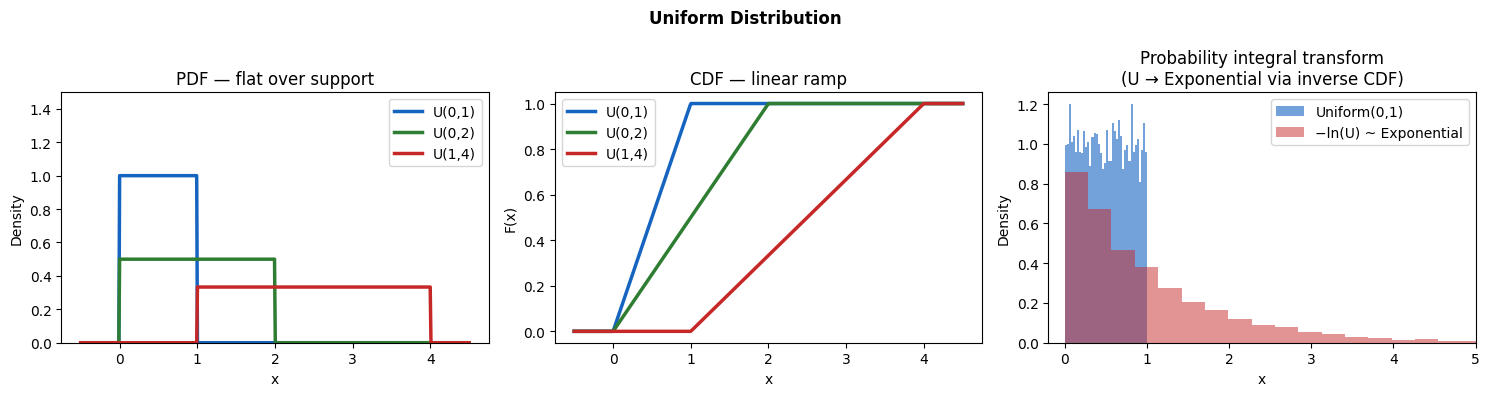

U(0,1): mean=0.500, std=0.289, skewness=0, kurtosis=1.8


In [2]:
x = np.linspace(-0.5, 4.5, 500)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Uniform Distribution', fontsize=12, fontweight='bold')

# PDF — different intervals
for A, B, color, label in [(0, 1, '#1565C0', 'U(0,1)'),
                             (0, 2, '#2E7D32', 'U(0,2)'),
                             (1, 4, '#C62828', 'U(1,4)')]:
    dist = stats.uniform(loc=A, scale=B-A)
    axes[0].plot(x, dist.pdf(x), color=color, linewidth=2.5, label=label)
axes[0].set_title('PDF — flat over support')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].set_ylim(0, 1.5)
axes[0].legend()

# CDF
for A, B, color, label in [(0, 1, '#1565C0', 'U(0,1)'),
                             (0, 2, '#2E7D32', 'U(0,2)'),
                             (1, 4, '#C62828', 'U(1,4)')]:
    dist = stats.uniform(loc=A, scale=B-A)
    axes[1].plot(x, dist.cdf(x), color=color, linewidth=2.5, label=label)
axes[1].set_title('CDF — linear ramp')
axes[1].set_xlabel('x'); axes[1].set_ylabel('F(x)')
axes[1].legend()

# Probability integral transform: U(0,1) → any distribution
np.random.seed(42)
u = np.random.uniform(0, 1, 5000)
# Transform to exponential via inverse CDF: X = -ln(U)
exp_sample = -np.log(u)
axes[2].hist(u, bins=40, density=True, alpha=0.6, color='#1565C0', label='Uniform(0,1)')
axes[2].hist(exp_sample, bins=40, density=True, alpha=0.5, color='#C62828', label='−ln(U) ~ Exponential')
axes[2].set_title('Probability integral transform\n(U → Exponential via inverse CDF)')
axes[2].set_xlabel('x'); axes[2].set_ylabel('Density')
axes[2].set_xlim(-0.2, 5)
axes[2].legend()

plt.tight_layout()
plt.show()

# Summary stats
A, B = 0, 1
print(f"U({A},{B}): mean={(A+B)/2:.3f}, std={(B-A)/np.sqrt(12):.3f}, skewness=0, kurtosis=1.8")

## Key Takeaways

| | |
|---|---|
| **Shape** | Flat rectangle — equal probability everywhere in [A, B] |
| **Kurtosis** | 1.8 < 3 (platykurtic — lighter tails than Normal) |
| **RNG foundation** | All distributions derived from U(0,1) via inverse CDF transform |
| **Probability integral transform** | If X ~ F, then F(X) ~ U(0,1); conversely X = F⁻¹(U) |
| **Estimation** | Â = min(sample), B̂ = max(sample) (MLE) |
| **Use cases** | Prior in Bayesian analysis (uninformative), simulation, rounding error models |